# Simulation 2 Target-Monitoring Figure


> Generate the focused Simulation 2 figure for target monitoring.


This notebook holds the post-reminder task-encoding condition fixed and varies rejected-sample context updating, with and without start-of-list context reinstatement.


In [1]:
import csv
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown
from jax import random
from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.helpers import find_project_root

from selective_interference_v2 import (
    PHASE_COLORS,
    Paradigm,
    add_phase_bands,
    light_to_dark_colors,
    load_fit_params,
    make_factory,
    make_is_emotional,
    make_is_target,
    prepare_sweep,
    run_sweep,
    save_figure,
    split_scales_for_cache,
    standard_remap,
)

warnings.filterwarnings("ignore")


In [2]:
# --- sweep configuration ---
PROJECT_ROOT = ""
FIT_PATH = "results/fits/Dupertuys2026_eCMR_source_only_phi_no_shared_support_best_of_1.json"
FIGURE_DIR = ""
FIGURE_STR = ""
RNG_SEED = 0

SWEEP_PARAM = "rejected_recall_drift_scale"
SWEEP_VALUES = [1.0, 0.75, 0.5, 0.25, 0.0]
SWEEP_XLABEL = "Off-target\nupdate ($\\kappa$)"
SWEEP_LABEL_FMT = "{:.2f}"

N_FILM = 16
N_BREAK = 16
N_INTERFERENCE = 16
N_FILLER = 16
EXPERIMENT_COUNT = 5000
MAX_RECALL = 48

TASK_MCF_SCALE = 2.0
FILM_EMOTIONAL = True
INTERFERENCE_EMOTIONAL = False
CACHE_AFTER = "filler"
EXTRA_FIXED_SCALES = {
    "source_learning_baseline": 0.05,
    "film_source_start_drift_rate": 0.5,
    "primacy_scale": 0.1,
    "primacy_decay": 1.5,
}

BASE_FIXED_SCALES = {
    "break_drift_scale": 1.0,
    "break_mcf_scale": 1.0,
    "reminder_start_drift_scale": 1.0,
    "reminder_drift_scale": 1.0,
    "interference_mcf_scale": TASK_MCF_SCALE,
    "filler_drift_scale": 1.0,
    "filler_mcf_scale": 1.0,
    "tau_scale": 1.0,
}

START_CONTEXT_CONDITIONS = {
    "No start-of-list reinstatement": 0.0,
    "With start-of-list reinstatement": 1.0,
}


In [3]:
# Parameters
PROJECT_ROOT = "/Users/jordangunn/workspace/selective_interference_v2"
FIGURE_DIR = "figures"
FIGURE_STR = "simulation2_target_monitoring"


In [4]:
#| output: asis
if PROJECT_ROOT:
    project_root = Path(PROJECT_ROOT)
else:
    project_root = Path(find_project_root())

fit_path = project_root / FIT_PATH
figure_dir = project_root / FIGURE_DIR if FIGURE_DIR else None
sweep_values = np.asarray(SWEEP_VALUES, dtype=float)
base_fixed_scales = {**BASE_FIXED_SCALES, **EXTRA_FIXED_SCALES}

params, n_subjects = load_fit_params(fit_path)
paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    experiment_count=EXPERIMENT_COUNT,
    max_recall=MAX_RECALL,
)
factory = make_factory(
    is_emotional=make_is_emotional(
        paradigm,
        film_emotional=FILM_EMOTIONAL,
        interference_emotional=INTERFERENCE_EMOTIONAL,
    ),
    is_target=make_is_target(paradigm),
)
rng = random.PRNGKey(RNG_SEED)

Markdown(
    f"Loaded {n_subjects} fit parameter set(s). Running {len(sweep_values)} off-target update values "
    f"for {len(START_CONTEXT_CONDITIONS)} start-context conditions with {EXPERIMENT_COUNT} simulated trials per value."
)


Loaded 1 fit parameter set(s). Running 5 off-target update values for 2 start-context conditions with 5000 simulated trials per value.

In [5]:
def position_phase_labels(paradigm):
    return (
        ["film"] * paradigm.n_film
        + ["break"] * paradigm.n_break
        + ["task"] * paradigm.n_interference
        + ["filler"] * paradigm.n_filler
    )


def write_rows(path, fieldnames, rows):
    os.makedirs(path.parent, exist_ok=True)
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def phase_recall_totals(spc):
    totals = {}
    for phase in sorted(set(position_phase)):
        positions = [idx for idx, value in enumerate(position_phase) if value == phase]
        totals[phase] = float(np.sum(spc[positions]))
    return totals


def off_target_film_return_probability(recalls, phase_labels, n_film):
    numerator = 0
    denominator = 0
    for row in recalls:
        sampled = [int(value) for value in row if value > 0]
        seen_film = set()
        for idx in range(len(sampled) - 1):
            current = sampled[idx]
            next_sample = sampled[idx + 1]
            if 1 <= current <= n_film:
                seen_film.add(current)
                continue
            if len(seen_film) >= n_film:
                continue
            denominator += 1
            if 1 <= next_sample <= n_film:
                numerator += 1
                seen_film.add(next_sample)
    probability = np.nan if denominator == 0 else numerator / denominator
    return probability, denominator, numerator


position_phase = position_phase_labels(paradigm)
n_presented = len(position_phase)


In [6]:
pre_cache_scales, post_cache_scales = split_scales_for_cache(
    base_fixed_scales,
    CACHE_AFTER,
)
prepared = prepare_sweep(
    params,
    paradigm,
    factory,
    cache_after=CACHE_AFTER,
    **pre_cache_scales,
)

condition_outputs = {}
for condition, start_context_scale in START_CONTEXT_CONDITIONS.items():
    recalls, rng = run_sweep(
        prepared,
        rng,
        **post_cache_scales,
        start_drift_scale=start_context_scale,
        **{SWEEP_PARAM: sweep_values},
    )
    condition_outputs[condition] = np.asarray(recalls)


In [7]:
spc_rows = []
recovery_rows = []
phase_rows = []
spc_curves = {}
recovery_curves = {}

for condition, recalls_4d in condition_outputs.items():
    spc_curves[condition] = []
    recovery_curves[condition] = []
    start_context_scale = START_CONTEXT_CONDITIONS[condition]
    for value_index, value in enumerate(sweep_values):
        raw_recalls = recalls_4d[value_index].reshape(-1, recalls_4d.shape[-1])
        remapped_recalls = np.asarray(
            standard_remap(
                raw_recalls,
                paradigm,
                show_break=True,
            )
        )
        spc = np.asarray(fixed_pres_spc(remapped_recalls, n_presented), dtype=float)
        totals = phase_recall_totals(spc)
        recovery, denominator, numerator = off_target_film_return_probability(
            remapped_recalls,
            position_phase,
            paradigm.n_film,
        )

        spc_curves[condition].append(spc)
        recovery_curves[condition].append(recovery)

        for position, phase in enumerate(position_phase, start=1):
            spc_rows.append({
                "start_context_condition": condition,
                "start_context_scale": start_context_scale,
                "kappa": value,
                "position": position,
                "phase": phase,
                "recall_probability": spc[position - 1],
            })
        recovery_rows.append({
            "start_context_condition": condition,
            "start_context_scale": start_context_scale,
            "kappa": value,
            "film_return_probability": recovery,
            "transition_count": denominator,
            "film_return_count": numerator,
        })
        for phase, total in totals.items():
            phase_rows.append({
                "start_context_condition": condition,
                "start_context_scale": start_context_scale,
                "kappa": value,
                "phase": phase,
                "recall_probability_mass": total,
            })


In [8]:
if figure_dir is not None and FIGURE_STR:
    write_rows(
        figure_dir / f"{FIGURE_STR}_spc.csv",
        [
            "start_context_condition",
            "start_context_scale",
            "kappa",
            "position",
            "phase",
            "recall_probability",
        ],
        spc_rows,
    )
    write_rows(
        figure_dir / f"{FIGURE_STR}_offtarget_recovery.csv",
        [
            "start_context_condition",
            "start_context_scale",
            "kappa",
            "film_return_probability",
            "transition_count",
            "film_return_count",
        ],
        recovery_rows,
    )
    write_rows(
        figure_dir / f"{FIGURE_STR}_phase_totals.csv",
        [
            "start_context_condition",
            "start_context_scale",
            "kappa",
            "phase",
            "recall_probability_mass",
        ],
        phase_rows,
    )


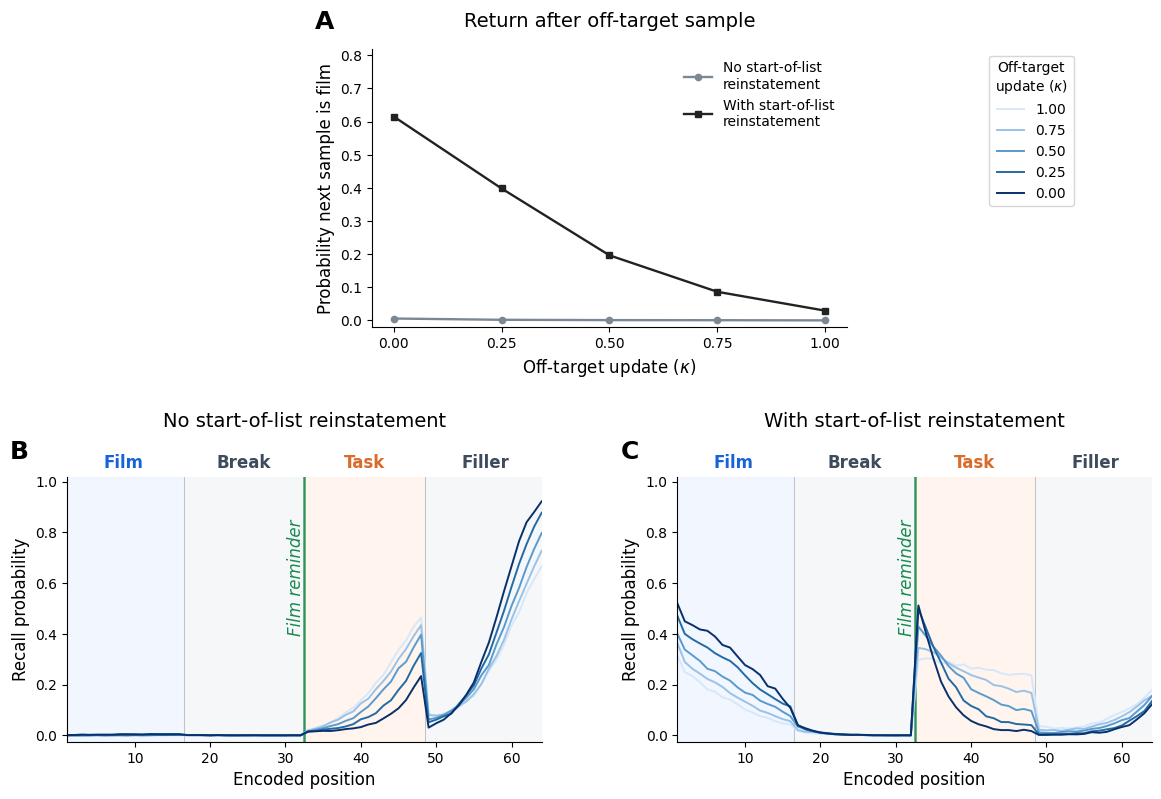

In [9]:
PANEL_LETTER_FONTSIZE = 18
PANEL_TITLE_FONTSIZE = 14
STRUCTURAL_FONTSIZE = 12
SUPPORT_FONTSIZE = 10


CONDITION_TITLES = {
    "No start-of-list reinstatement": "No start-of-list reinstatement",
    "With start-of-list reinstatement": "With start-of-list reinstatement",
}

CONDITION_STYLES = {
    "No start-of-list reinstatement": {
        "color": "#7C8794",
        "marker": "o",
        "label": "No start-of-list\nreinstatement",
    },
    "With start-of-list reinstatement": {
        "color": "#222222",
        "marker": "s",
        "label": "With start-of-list\nreinstatement",
    },
}


def add_panel_label(axis, label, x=-0.12):
    axis.text(
        x,
        1.14,
        label,
        transform=axis.transAxes,
        fontsize=PANEL_LETTER_FONTSIZE,
        fontweight="bold",
        va="top",
        ha="left",
    )


def add_phase_boundaries(axis):
    boundaries = np.cumsum([
        paradigm.n_film,
        paradigm.n_break,
        paradigm.n_interference,
    ]) + 0.5
    for boundary in boundaries:
        axis.axvline(boundary, color="#7C8794", linewidth=0.7, alpha=0.45, zorder=1)


def add_reminder_marker(axis):
    reminder_x = paradigm.n_film + paradigm.n_break + 0.5
    axis.axvline(
        reminder_x,
        color=PHASE_COLORS["reminder"],
        linewidth=1.8,
        alpha=0.85,
        zorder=2,
    )
    axis.text(
        reminder_x - 1.05,
        0.62,
        "Film reminder",
        ha="center",
        va="center",
        fontsize=STRUCTURAL_FONTSIZE,
        fontstyle="italic",
        color=PHASE_COLORS["reminder"],
        rotation=90,
        rotation_mode="anchor",
        transform=axis.get_xaxis_transform(),
        clip_on=False,
        zorder=3,
    )


def style_position_axis(axis, ylabel, title):
    add_phase_bands(axis, position_phase, fontsize=STRUCTURAL_FONTSIZE)
    add_phase_boundaries(axis)
    add_reminder_marker(axis)
    axis.set_title(title, fontsize=PANEL_TITLE_FONTSIZE, pad=36)
    axis.set_xlabel("Encoded position", fontsize=STRUCTURAL_FONTSIZE)
    axis.set_ylabel(ylabel, fontsize=STRUCTURAL_FONTSIZE)
    axis.set_xlim(1, n_presented)
    axis.tick_params(labelsize=SUPPORT_FONTSIZE)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)


def plot_spc_panel(axis, condition, label):
    style_position_axis(axis, "Recall probability", CONDITION_TITLES[condition])
    colors = light_to_dark_colors(len(sweep_values))
    positions = np.arange(1, n_presented + 1)
    for color, value, curve in zip(colors, sweep_values, spc_curves[condition]):
        axis.plot(
            positions,
            curve,
            color=color,
            linewidth=1.4,
            label=SWEEP_LABEL_FMT.format(value),
        )
    axis.set_ylim(-0.025, 1.02)
    add_panel_label(axis, label)


def plot_recovery_panel(axis, label):
    for condition, values in recovery_curves.items():
        style = CONDITION_STYLES[condition]
        axis.plot(
            sweep_values,
            values,
            color=style["color"],
            marker=style["marker"],
            linewidth=1.7,
            markersize=4.5,
            label=style["label"],
        )
    axis.set_title("Return after off-target sample", fontsize=PANEL_TITLE_FONTSIZE, pad=16)
    axis.set_xlabel("Off-target update ($\\kappa$)", fontsize=STRUCTURAL_FONTSIZE)
    axis.set_ylabel("Probability next sample is film", fontsize=STRUCTURAL_FONTSIZE)
    axis.set_xlim(-0.05, 1.05)
    axis.set_ylim(-0.02, 0.82)
    axis.set_xticks(np.linspace(0.0, 1.0, 5))
    axis.tick_params(labelsize=SUPPORT_FONTSIZE)
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.legend(
        loc="upper right",
        fontsize=SUPPORT_FONTSIZE,
        frameon=False,
        handlelength=2.0,
    )
    add_panel_label(axis, label)


fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(
    2,
    4,
    height_ratios=[1.05, 1.0],
    hspace=0.55,
    wspace=0.80,
)

axis_a = fig.add_subplot(gs[0, 1:3])
legend_axis = fig.add_subplot(gs[0, 3])
axis_b = fig.add_subplot(gs[1, 0:2])
axis_c = fig.add_subplot(gs[1, 2:4], sharey=axis_b)
legend_axis.axis("off")

plot_recovery_panel(axis_a, "A")
plot_spc_panel(axis_b, "No start-of-list reinstatement", "B")
plot_spc_panel(axis_c, "With start-of-list reinstatement", "C")
axis_c.tick_params(labelleft=True)

handles, labels = axis_b.get_legend_handles_labels()
legend = legend_axis.legend(
    handles,
    labels,
    title=SWEEP_XLABEL,
    loc="upper left",
    fontsize=SUPPORT_FONTSIZE,
    title_fontsize=SUPPORT_FONTSIZE,
)
legend.get_title().set_multialignment("center")
legend.get_title().set_ha("center")

save_figure(str(figure_dir) if figure_dir is not None else "", FIGURE_STR)


In [10]:
for condition in START_CONTEXT_CONDITIONS:
    low = -1
    high = 0
    film_positions = [i for i, phase in enumerate(position_phase) if phase == "film"]
    task_positions = [i for i, phase in enumerate(position_phase) if phase == "task"]
    filler_positions = [i for i, phase in enumerate(position_phase) if phase == "filler"]
    low_film = float(np.sum(spc_curves[condition][low][film_positions]))
    high_film = float(np.sum(spc_curves[condition][high][film_positions]))
    low_task = float(np.sum(spc_curves[condition][low][task_positions]))
    high_task = float(np.sum(spc_curves[condition][high][task_positions]))
    low_filler = float(np.sum(spc_curves[condition][low][filler_positions]))
    high_filler = float(np.sum(spc_curves[condition][high][filler_positions]))
    low_recovery = recovery_curves[condition][low]
    high_recovery = recovery_curves[condition][high]
    print(condition)
    print(f"  Film recall probability mass, kappa 1.00 -> 0.00: {high_film:.2f} -> {low_film:.2f}")
    print(f"  Task recall probability mass, kappa 1.00 -> 0.00: {high_task:.2f} -> {low_task:.2f}")
    print(f"  Filler recall probability mass, kappa 1.00 -> 0.00: {high_filler:.2f} -> {low_filler:.2f}")
    print(f"  Film return after off-target sample, kappa 1.00 -> 0.00: {high_recovery:.3f} -> {low_recovery:.3f}")


No start-of-list reinstatement
  Film recall probability mass, kappa 1.00 -> 0.00: 0.00 -> 0.06
  Task recall probability mass, kappa 1.00 -> 0.00: 3.05 -> 1.08
  Filler recall probability mass, kappa 1.00 -> 0.00: 4.61 -> 6.48
  Film return after off-target sample, kappa 1.00 -> 0.00: 0.000 -> 0.006
With start-of-list reinstatement
  Film recall probability mass, kappa 1.00 -> 0.00: 2.26 -> 5.05
  Task recall probability mass, kappa 1.00 -> 0.00: 4.28 -> 2.03
  Filler recall probability mass, kappa 1.00 -> 0.00: 1.11 -> 0.43
  Film return after off-target sample, kappa 1.00 -> 0.00: 0.030 -> 0.615
